# Customer Segmentation Analysis (RFM Model)

### 🎯 Project Objective
The goal of this project is to analyze customer purchasing behavior and categorize them into distinct segments. By using **Recency, Frequency, and Monetary (RFM)** metrics, we provide actionable insights to optimize marketing strategies, increase customer retention, and maximize revenue.

### 📊 Key Business Questions
* Who are our most loyal and high-value customers (**Champions**)?
* Which customers are at risk of leaving (**Churn Risk**)?
* Where should we focus our marketing budget to get the highest ROI?

### 🛠️ Tech Stack
* **Language:** Python
* **Libraries:** Pandas (Data Manipulation), Matplotlib/Seaborn (Visualization)
* **Methodology:** Quantile-based binning and behavioral segmentation

In [172]:
import pandas as pd
import datetime
import seaborn as sns
import matplotlib.pyplot as plt

In [173]:
df1 = pd.read_csv('online_retail_09_10.csv')
df2 = pd.read_csv('online_retail_10_11.csv')
df = pd.concat([df1, df2], ignore_index=True)
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom


In [174]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     243007
Country             0
dtype: int64


In [175]:
null_mask = df.isnull().any(axis=1)
null_rows = df[null_mask]
display(null_rows.head())


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
263,489464,21733,85123a mixed,-96,12/1/2009 10:52,0.00,NaN,United Kingdom
283,489463,71477,short,-240,12/1/2009 10:52,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,12/1/2009 10:53,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,12/1/2009 11:44,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,12/1/2009 11:49,0.55,NaN,United Kingdom


In [176]:
#Cleaning
df.dropna(subset=['CustomerID'], inplace=True)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

#Modify
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df["TotalPrice"]=df["Quantity"]*df["UnitPrice"]
df["CustomerID"]=df["CustomerID"].astype(int)

display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [177]:
#Setting reference date
Ref_date=df['InvoiceDate'].max() + datetime.timedelta(days=1)

rfm=df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (Ref_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalPrice': 'sum'                                      # Monetary
})


#Grouping by Customer to find length since last purchase, frequency of purchase and total spent
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm=rfm.reset_index()
print(rfm.head(10))

   CustomerID  Recency  Frequency  Monetary
0       12346      326         12  77556.46
1       12347        2          8   5633.32
2       12348       75          5   2019.40
3       12349       19          4   4428.69
4       12350      310          1    334.40
5       12351      375          1    300.93
6       12352       36         10   2849.84
7       12353      204          2    406.76
8       12354      232          1   1079.40
9       12355      214          2    947.61


In [178]:
#Create score for Recency Frequency and total by binning it into 5. 
# 1 is lowest and 5 is the highest for each
rfm["R_Score"] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

rfm["F_Score"] = pd.qcut(rfm['Frequency'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])

rfm["M_Score"] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['Total_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

rfm["RFM_CombineScore"] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

display(rfm.head(10))

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Total_Score,RFM_CombineScore
0,12346,326,12,77556.46,2,5,5,12,255
1,12347,2,8,5633.32,5,4,5,14,545
2,12348,75,5,2019.40,3,4,4,11,344
3,12349,19,4,4428.69,5,3,5,13,535
4,12350,310,1,334.40,2,1,2,5,212
5,12351,375,1,300.93,2,1,2,5,212
6,12352,36,10,2849.84,4,5,4,13,454
7,12353,204,2,406.76,2,2,2,6,222
8,12354,232,1,1079.40,2,1,3,6,213
9,12355,214,2,947.61,2,2,3,7,223


In [179]:
display(rfm[rfm["Total_Score"]>13].sort_values(by=["Total_Score"],ascending=False).head())

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Total_Score,RFM_CombineScore
5566,17975,15,24,7028.83,5,5,5,15,555
5631,18041,12,38,8752.38,5,5,5,15,555
5735,18145,13,11,5617.79,5,5,5,15,555
5734,18144,8,19,5058.00,5,5,5,15,555
5634,18044,4,18,3505.61,5,5,5,15,555


In [180]:
#Labelling customer category

#Combine R and F score into a single string for mapping
rfm['Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str)

#Define the standard RFM Map
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Lose Them',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}
rfm['Segment'] = rfm['Segment'].replace(seg_map, regex=True)

print(rfm[['CustomerID', 'Total_Score', 'RFM_CombineScore', 'Segment']].head())

   CustomerID  Total_Score RFM_CombineScore              Segment
0       12346           12              255      Can't Lose Them
1       12347           14              545            Champions
2       12348           11              344      Loyal Customers
3       12349           13              535  Potential Loyalists
4       12350            5              212          Hibernating


In [181]:
# This calculates the Average stats for each group
segment_analysis = rfm.groupby('Segment').agg({
    'Recency': ['mean', 'count'],
    'Frequency': 'mean',
    'Monetary': 'mean' 
}).round(1)

print(segment_analysis)

                    Recency       Frequency Monetary
                       mean count      mean     mean
Segment                                             
About to Sleep        107.1   385       1.4    534.1
At Risk               372.7   753       3.9   1382.1
Can't Lose Them       331.2    71      15.9   8355.7
Champions               8.6   837      19.3  10901.1
Hibernating           459.3  1523       1.3    438.0
Loyal Customers        67.1  1161       9.8   4211.8
Need Attention        113.4   266       3.2   1283.7
New Customers          10.5    54       1.0    360.7
Potential Loyalists    25.8   714       2.6   1155.7
Promising              38.8   114       1.0    319.4


In [182]:
# Grouping for specific action
at_risk_count = rfm[rfm["Segment"].isin(["Can't Lose Them", "At Risk"])].shape[0]
vip_count = rfm[rfm["Segment"].isin(["Champions", "Loyal Customers"])].shape[0]
potential_count=rfm[rfm["Segment"].isin(["New Customers", "Promising"])].shape[0]

print(f"--- ACTION REPORT ---")
print(f"✅ VIP Tier: {vip_count} customers (Maintain)")
print(f"✅ Potential Tier: {potential_count} customers (Maintain)")
print(f"⚠️ Danger Tier: {at_risk_count} customers (Save immediately)")

--- ACTION REPORT ---
✅ VIP Tier: 1998 customers (Maintain)
✅ Potential Tier: 168 customers (Maintain)
⚠️ Danger Tier: 824 customers (Save immediately)


C:\Users\thoma\AppData\Local\Temp\ipykernel_38064\3830066724.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_money, x='Monetary', y='Segment', palette='magma')


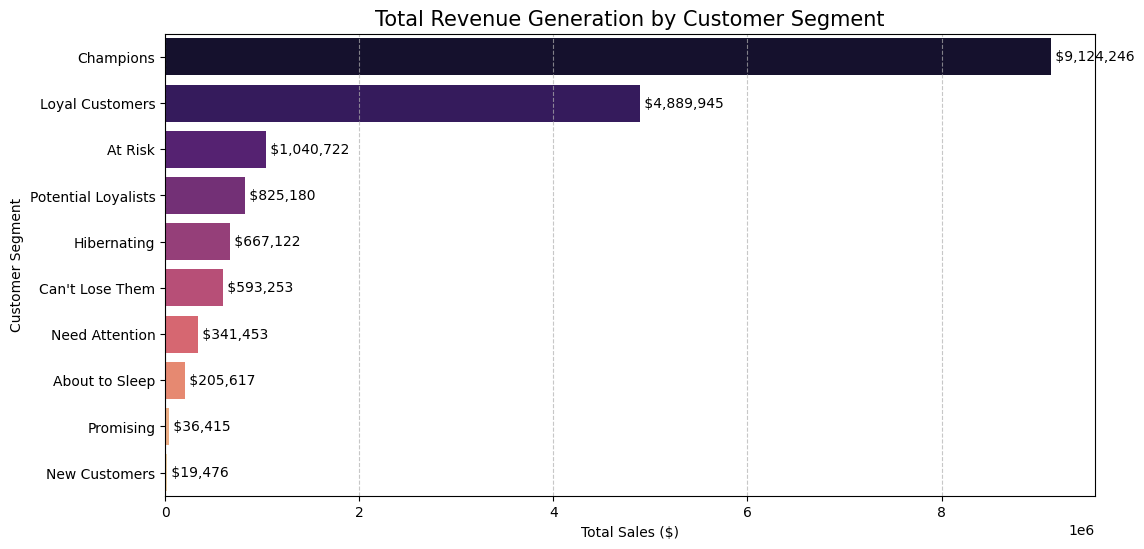

In [183]:
segment_money = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=segment_money, x='Monetary', y='Segment', palette='magma')

# Annotate with actual numbers (The "Pro" touch)
for index, value in enumerate(segment_money['Monetary']):
    plt.text(value, index, f' ${value:,.0f}', va='center')

plt.title('Total Revenue Generation by Customer Segment', fontsize=15)
plt.xlabel('Total Sales ($)')
plt.ylabel('Customer Segment')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Champions: Focus on loyalty programs and reviews. They don't need discounts to buy.

At Risk: High priority. These customers are high-value but fading. Send a "20% Off" win-back campaign.

Hibernating: Low priority. Don't waste marketing budget here; the ROI will be too low.